# Oferta x demanda aos domingos — resultado agregado, sem recorte espacial

Mede a **queda da razão lugares ofertados por embarque aos domingos** para a cidade inteira, sem
nenhum recorte territorial. É o resultado mais auditável do projeto, porque não depende de três
coisas das quais o resto do relatório depende:

- **Não usa `zona_emb`**, que no domingo é imputada (`01_criacao_de_bases/05_imputa_zona_domingo.ipynb`)
  sobre uma variável que a própria SPTrans classifica como estimativa.
- **Não usa a bilhetagem** como fonte principal: a demanda vem da série oficial de passageiros
  transportados, publicada pela Prefeitura/SPTrans e portanto verificável por terceiros.
- **Não fica presa à janela de 4 meses**: `Partidas.csv` cobre 202301–202412 nos três tipos de dia e
  a série oficial cobre os 731 dias de 2023-2024. Só a bilhetagem era limitada a abril, maio,
  setembro e outubro.

Fontes: `Partidas.csv` e `Tecnologias.csv` (`<RAIZ_SPTRANS>\pedido 096412- oferta`) e
`../outputs/01/Dados_4Meses_Domingos_2023_2024_site.parquet`
(série oficial compilada por `01_criacao_de_bases/03_cria_base_oficial.ipynb`; apesar do nome,
cobre todos os 731 dias).

## Seção 0 — imports e configuração

In [1]:
import os
import re
from pathlib import Path

import duckdb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# Raiz das fontes brutas (fora do repo). Se a unidade mudar, muda so esta linha.
RAIZ_SPTRANS = r"C:\Users\9837292\Desktop\SSD\SPTrans"
DIR_OFERTA = os.path.join(RAIZ_SPTRANS, "pedido 096412- oferta")
CAMINHO_PARTIDAS = os.path.join(DIR_OFERTA, "Partidas.csv").replace("\\", "/")  # DuckDB quer barra normal
CAMINHO_TECNOLOGIAS = os.path.join(DIR_OFERTA, "Tecnologias.csv")
CAMINHO_OFICIAL = "../outputs/01/Dados_4Meses_Domingos_2023_2024_site.parquet"

DIR_IMG = Path("../docs/img")
DIR_TABELAS = Path("../outputs/02/tabelas")   # namespace da etapa produtora (ver CLAUDE.md)
DIR_IMG.mkdir(parents=True, exist_ok=True)
DIR_TABELAS.mkdir(parents=True, exist_ok=True)
SALVAR_FIG = dict(dpi=150, bbox_inches="tight", facecolor="white")

ANOS = ["2023", "2024"]
JANELA_PRINCIPAL = [f"{m:02d}" for m in range(1, 13)]   # os 12 meses de cada ano
JANELA_SENSIBILIDADE = ["04", "05", "09", "10"]         # a janela usada no resto do relatorio

# Rotulos de exibicao (as tabelas exportadas vao direto para o site)
ROTULO_TIPO_DIA = {"domingo": "domingo", "sabado": "sábado", "util": "dia útil"}
ORDEM_TIPO_DIA = ["domingo", "sabado", "util"]

## Seção 1 — calendário: o que entra e o que sai da comparação

Três correções de calendário, todas explícitas e todas com o efeito medido na Seção 7.

**1. A data de início da política.** A gratuidade dominical não começou em 1º de janeiro de 2024: ela
começa em **17/12/2023**, e isso está no próprio dado — `of_pagantes` nos domingos cai de ~55% do
total para 0,1% exatamente nessa data (Seção 6). Os domingos de 17, 24 e 31/12/2023 são portanto
**já tratados**, e contá-los no "antes" contamina a linha de base. O recorte pré vai até 16/12/2023.

**2. Feriados classificados como dia útil.** `tipo_dia` vem do dia da semana, então feriados que caem
de segunda a sexta entram no controle como se fossem dia útil comum — com demanda muito abaixo do
normal. São 15 datas por ano (nacionais, estaduais de SP e municipais), listadas abaixo. Um feriado
que cai no sábado ou domingo é excluído do mesmo jeito, para manter o critério simétrico.

**3. Dias atípicos e outliers residuais.** Vésperas e recesso (24/12, 31/12, 02/01) saem por lista.
Depois disso, ainda sobram dias com volume muito abaixo do normal — a regra é marcar qualquer dia
com menos de 60% da mediana do seu próprio tipo de dia/ano. Ela pega três domingos de 2023 (01/10,
05/11 e 12/11) que aparecem na série oficial com cerca de um terço do volume habitual. Esses três
puxam a base de 2023 para baixo e, se mantidos, inflam o crescimento medido do domingo.

A célula abaixo **imprime tudo que foi excluído** — a exclusão nunca é silenciosa.

In [3]:
# Feriados nacionais, estaduais (SP) e municipais (cidade de SP). 09/07 = Revolucao
# Constitucionalista (estadual); 25/01 = aniversario da cidade; 20/11 = Consciencia Negra.
FERIADOS = {
    "2023": ["0101", "0125", "0220", "0221", "0407", "0421", "0501", "0608",
             "0709", "0907", "1012", "1102", "1115", "1120", "1225"],
    "2024": ["0101", "0125", "0212", "0213", "0329", "0421", "0501", "0530",
             "0709", "0907", "1012", "1102", "1115", "1120", "1225"],
}
# Vesperas e recesso: nao sao feriado legal, mas a demanda nao e a de um dia comum.
ATIPICOS = {"2023": ["1224", "1231"], "2024": ["0102", "1224", "1231"]}

DATA_INICIO_POLITICA = "20231217"  # confirmada na Secao 6
LIMIAR_OUTLIER = 0.60              # fracao da mediana do proprio tipo_dia/ano

DATAS_FERIADO = {ano + mmdd for ano, ds in FERIADOS.items() for mmdd in ds}
DATAS_ATIPICAS = {ano + mmdd for ano, ds in ATIPICOS.items() for mmdd in ds}

In [4]:
# Serie oficial agregada por dia (cidade inteira). `data` e AAAAMMDD (string).
dia_oficial = duckdb.sql(f"""
    SELECT data, Ano, Mes, tipo_dia,
           sum(of_total)    AS embarques,
           sum(of_pagantes) AS pagantes
    FROM read_parquet('{CAMINHO_OFICIAL}')
    GROUP BY 1, 2, 3, 4
    ORDER BY data
""").df()

print(f"{len(dia_oficial)} dias, {dia_oficial['data'].min()} a {dia_oficial['data'].max()}")
print(dia_oficial.groupby(["Ano", "tipo_dia"]).size().unstack().to_string())

731 dias, 20230101 a 20241231
tipo_dia  domingo  sabado  util
Ano                            
2023           53      52   260
2024           52      52   262


In [5]:
dias = dia_oficial.copy()
dias["feriado"] = dias["data"].isin(DATAS_FERIADO)
dias["atipico"] = dias["data"].isin(DATAS_ATIPICAS)
dias["pos_politica_2023"] = (dias["Ano"] == "2023") & (dias["data"] >= DATA_INICIO_POLITICA)

# outlier so faz sentido depois de tirar feriados/atipicos: a mediana de referencia
# precisa ser a dos dias normais.
normais = dias.loc[~dias["feriado"] & ~dias["atipico"] & ~dias["pos_politica_2023"]].copy()
mediana_ref = normais.groupby(["Ano", "tipo_dia"])["embarques"].transform("median")
normais["outlier"] = normais["embarques"] < LIMIAR_OUTLIER * mediana_ref
dias = dias.merge(normais[["data", "outlier"]], on="data", how="left")
dias["outlier"] = dias["outlier"].fillna(False)

dias["excluido"] = dias["feriado"] | dias["atipico"] | dias["pos_politica_2023"] | dias["outlier"]
demanda_dia = dias.loc[~dias["excluido"]].copy()

print("=== dias excluidos por motivo ===")
for motivo in ["feriado", "atipico", "pos_politica_2023", "outlier"]:
    sub = dias.loc[dias[motivo]]
    print(f"\n{motivo}: {len(sub)} dias")
    if motivo in ("outlier", "pos_politica_2023"):
        print(sub[["data", "tipo_dia", "embarques"]].to_string(index=False))

print("\n=== dias mantidos por Ano x tipo_dia ===")
print(demanda_dia.groupby(["Ano", "tipo_dia"]).size().unstack().to_string())

=== dias excluidos por motivo ===

feriado: 30 dias

atipico: 5 dias

pos_politica_2023: 15 dias
    data tipo_dia  embarques
20231217  domingo  3006910.0
20231218     util  6287691.0
20231219     util  6466823.0
20231220     util  6527413.0
20231221     util  6308344.0
20231222     util  5911348.0
20231223   sabado  3799943.0
20231224  domingo  2563400.0
20231225     util  1488418.0
20231226     util  4515553.0
20231227     util  5084529.0
20231228     util  5052953.0
20231229     util  4669770.0
20231230   sabado  2953999.0
20231231  domingo  2197182.0

outlier: 3 dias
    data tipo_dia  embarques
20231001  domingo   732606.0
20231105  domingo   701114.0
20231112  domingo   738282.0

=== dias mantidos por Ano x tipo_dia ===
tipo_dia  domingo  sabado  util
Ano                            
2023           45      50   238
2024           51      49   248


## Seção 2 — demanda: média diária pela série oficial

**Média diária dentro de cada mês, depois média entre os meses da janela** — nunca soma bruta do
período. É a mesma receita de `pivot_diario` em
`03_comparacoes/compara_demanda_oferta_genero_idade.ipynb`. Aqui a normalização importa menos que
lá (a série oficial tem todos os dias dos dois anos, não uma entrega desbalanceada), mas o mês tem
número variável de domingos — 4 ou 5 — e a média em dois estágios remove isso.

In [6]:
def media_diaria(df, meses, coluna="embarques"):
    """Media diaria dentro de cada mes, depois media entre os meses da janela."""
    sub = df.loc[df["Mes"].isin(meses)]
    por_mes = sub.groupby(["Ano", "Mes", "tipo_dia"])[coluna].mean()
    return por_mes.groupby(level=["Ano", "tipo_dia"]).mean().rename(coluna)


demanda = media_diaria(demanda_dia, JANELA_PRINCIPAL)
print("Embarques por dia, media dos 12 meses:")
print(demanda.unstack("Ano").round(0).to_string())

Embarques por dia, media dos 12 meses:
Ano            2023       2024
tipo_dia                      
domingo   2145758.0  2901942.0
sabado    4014329.0  4125557.0
util      6651301.0  6923950.0


## Seção 3 — oferta: partidas e lugares por dia típico

**`Partidas.csv` já é a programação de um dia típico de cada tipo, em cada mês** — a descrição de
campos da SPTrans diz "com base no planejamento de partidas no dia primeiro de cada mês", e cada
linha do arquivo é uma partida programada (`Sentido`, `Vira`, `Horario`). Logo `n_partidas` é
nativamente uma grandeza **diária**: não existe do lado da oferta a armadilha de somar o mês e medir
o tamanho do período em vez do serviço. É justamente isso que torna a oferta diretamente comparável
com a média diária da demanda da Seção 2.

`Tecnologias.csv` só traz `UTIL` (achado documentado no CLAUDE.md), mas a composição de frota é uma
propriedade física da linha que não muda por ser domingo — o que muda entre tipos de dia é a
frequência, e essa vem de `Partidas.csv`, que cobre `DOMG` explicitamente. A capacidade dominical é
portanto **inferida da frequência observada**, não suposta constante.

A tabela `CAPACIDADE_POR_CATEGORIA` abaixo é **cópia** da definição canônica em
`03_comparacoes/compara_demanda_oferta_genero_idade.ipynb` (Seção 4) — mantidas em sincronia à mão.
Ela é uma aproximação a partir de dado público, não um valor certificado; por isso a Seção 4 publica
também a métrica em **partidas**, que não depende dela.

In [7]:
# Copia da definicao canonica em 03_comparacoes/compara_demanda_oferta_genero_idade.ipynb (Secao 4).
CAPACIDADE_POR_CATEGORIA = {
    "Miniônibus": 40,
    "Micro Ônibus": 30,
    "Midiônibus": 60,
    "Midiônibus Rural": 55,
    "Básico": 80,
    "Padron": 95,
    "Articulado": 150,
}


def categoria_base(tecnologia):
    """Normaliza 'eArticulado21' / 'Articulado18' -> 'Articulado' (remove prefixo 'e' e sufixo numerico)."""
    if tecnologia is None or str(tecnologia).startswith("Embarcacao"):
        return None
    s = tecnologia[1:] if tecnologia.startswith("e") else tecnologia
    return re.sub(r"\d+$", "", s).strip()


def capacidade_de(tecnologia):
    return CAPACIDADE_POR_CATEGORIA.get(categoria_base(tecnologia))

In [8]:
# encoding="utf-8" e obrigatorio: latin-1 mojibaka os nomes acentuados das tecnologias.
tecnologias = pd.read_csv(CAMINHO_TECNOLOGIAS, encoding="utf-8")
tecnologias = tecnologias.loc[tecnologias["Ano Mês"].between(202301, 202412)].copy()

print("Tipo Dia presente em Tecnologias.csv:", tecnologias["Tipo Dia"].unique())  # esperado: so UTIL

tecnologias["capacidade_nominal"] = tecnologias["Tecnologia"].map(capacidade_de)
sem_capacidade = tecnologias.loc[tecnologias["capacidade_nominal"].isna(), "Tecnologia"].unique()
print("Tecnologias sem capacidade mapeada (esperado: so Embarcacao*):", list(sem_capacidade))
tecnologias = tecnologias.dropna(subset=["capacidade_nominal"])

tecnologias["Ano"] = tecnologias["Ano Mês"].astype(str).str[:4]
tecnologias["Mes"] = tecnologias["Ano Mês"].astype(str).str[4:]

capacidade_media_veiculo = (
    tecnologias
    .groupby(["Linha", "Ano", "Mes"])
    .apply(lambda t: (t["Frota"] * t["capacidade_nominal"]).sum() / t["Frota"].sum(),
           include_groups=False)
    .rename("capacidade_media_veiculo")
    .reset_index()
)
capacidade_media_veiculo.head()

Tipo Dia presente em Tecnologias.csv: <ArrowStringArray>
['UTIL']
Length: 1, dtype: str


Tecnologias sem capacidade mapeada (esperado: so Embarcacao*): ['Embarcacao60', 'Embarcacao30']


,Linha,Ano,Mes,capacidade_media_veiculo
0,1012-10,2023,01,40.0
1,1012-10,2023,02,40.0
2,1012-10,2023,03,40.0
3,1012-10,2023,04,40.0
4,1012-10,2023,05,40.0


In [9]:
# Uma linha de Partidas.csv = uma partida programada num dia tipico daquele tipo de dia.
partidas = duckdb.sql(f"""
    SELECT substr("Ano Mês"::VARCHAR, 1, 4) AS Ano,
           substr("Ano Mês"::VARCHAR, 5, 2) AS Mes,
           CASE "Tipo Dia" WHEN 'UTIL' THEN 'util'
                           WHEN 'SABD' THEN 'sabado'
                           WHEN 'DOMG' THEN 'domingo' END AS tipo_dia,
           "Linha" AS Linha,
           count(*) AS n_partidas
    FROM read_csv('{CAMINHO_PARTIDAS}')
    WHERE "Ano Mês" BETWEEN 202301 AND 202412
    GROUP BY 1, 2, 3, 4
""").df()

if partidas["tipo_dia"].isna().any():
    raise ValueError("Tipo Dia sem mapeamento em Partidas.csv — checar rotulos antes de seguir.")

oferta_linha = partidas.merge(capacidade_media_veiculo, on=["Linha", "Ano", "Mes"], how="left")
pct_sem_cap = 100 * (oferta_linha.loc[oferta_linha["capacidade_media_veiculo"].isna(), "n_partidas"].sum()
                     / oferta_linha["n_partidas"].sum())
print(f"Partidas sem capacidade media (linha ausente de Tecnologias.csv): {pct_sem_cap:.2f}% "
      f"— reportadas, nao interpoladas: entram em n_partidas e ficam de fora de lugares.")

oferta_linha["lugares"] = oferta_linha["n_partidas"] * oferta_linha["capacidade_media_veiculo"]

oferta_mes = (
    oferta_linha
    .groupby(["Ano", "Mes", "tipo_dia"])[["n_partidas", "lugares"]]
    .sum()
    .reset_index()
)
print()
print("Capacidade media por partida — so nas partidas que tem capacidade, senao os 0,77% sem")
print("capacidade entrariam no denominador e puxariam a media para baixo artificialmente:")
com_cap = oferta_linha.dropna(subset=["capacidade_media_veiculo"])
print((com_cap.groupby(["Ano", "tipo_dia"])[["lugares", "n_partidas"]].sum()
       .eval("lugares / n_partidas").unstack("Ano").round(2).to_string()))

Partidas sem capacidade media (linha ausente de Tecnologias.csv): 0.77% — reportadas, nao interpoladas: entram em n_partidas e ficam de fora de lugares.

Capacidade media por partida — so nas partidas que tem capacidade, senao os 0,77% sem
capacidade entrariam no denominador e puxariam a media para baixo artificialmente:
Ano        2023   2024
tipo_dia              
domingo   82.93  83.46
sabado    81.61  82.06
util      82.29  82.69


In [10]:
# Checagem: a soma de n_partidas tem que bater com uma contagem direta no CSV, sem deduplicacao.
conferencia = duckdb.sql(f"""
    SELECT substr("Ano Mês"::VARCHAR, 1, 4) AS Ano, count(*) AS n
    FROM read_csv('{CAMINHO_PARTIDAS}')
    WHERE "Ano Mês" BETWEEN 202301 AND 202412
    GROUP BY 1 ORDER BY 1
""").df().set_index("Ano")["n"]
calculado = oferta_mes.groupby("Ano")["n_partidas"].sum()
assert (conferencia == calculado).all(), (conferencia, calculado)
print("OK — n_partidas bate com a contagem direta em Partidas.csv:", calculado.to_dict())

OK — n_partidas bate com a contagem direta em Partidas.csv: {'2023': 4203185, '2024': 4203489}


## Seção 4 — a razão lugares por embarque

Duas métricas, de propósito:

- **`partidas_por_mil_embarques`** — 100% observada, não depende de nenhuma tabela de capacidade.
- **`lugares_por_embarque`** — a leitura em assentos, que depende de `CAPACIDADE_POR_CATEGORIA`.

Se as duas derem a mesma resposta, a conclusão não está pendurada na tabela de capacidade. O nível
absoluto de `lugares_por_embarque` é provisório; a **variação percentual** é o número defensável,
porque um erro constante de escala na capacidade se cancela na razão entre os dois anos.

`Sinal = Δ% domingo − Δ% dia útil` — a mesma métrica de isolamento usada no resto do relatório,
aplicada aqui à razão em vez de à demanda.

In [11]:
def resultado(meses, base_demanda):
    """Niveis por Ano x tipo_dia (media diaria) e as razoes derivadas, para uma janela de meses."""
    dem = media_diaria(base_demanda, meses).reset_index()
    ofe = (oferta_mes.loc[oferta_mes["Mes"].isin(meses)]
           .groupby(["Ano", "tipo_dia"])[["n_partidas", "lugares"]].mean().reset_index())
    t = dem.merge(ofe, on=["Ano", "tipo_dia"], how="inner")
    t["lugares_por_embarque"] = t["lugares"] / t["embarques"]
    t["partidas_por_mil_embarques"] = 1000 * t["n_partidas"] / t["embarques"]
    return t


def com_variacao(t, colunas):
    """Pivota Ano para coluna e acrescenta a variacao percentual 2024 vs 2023."""
    piv = t.pivot(index="tipo_dia", columns="Ano")
    out = pd.DataFrame(index=piv.index)
    for c in colunas:
        out[f"{c}_2023"] = piv[(c, "2023")]
        out[f"{c}_2024"] = piv[(c, "2024")]
        out[f"pct_{c}"] = 100 * (piv[(c, "2024")] / piv[(c, "2023")] - 1)
    return out.reindex(ORDEM_TIPO_DIA)


COLUNAS = ["embarques", "n_partidas", "lugares", "lugares_por_embarque", "partidas_por_mil_embarques"]
principal = com_variacao(resultado(JANELA_PRINCIPAL, demanda_dia), COLUNAS)
principal

,embarques_2023,embarques_2024,pct_embarques,n_partidas_2023,n_partidas_2024,pct_n_partidas,lugares_2023,lugares_2024,pct_lugares,lugares_por_embarque_2023,lugares_por_embarque_2024,pct_lugares_por_embarque,partidas_por_mil_embarques_2023,partidas_por_mil_embarques_2024,pct_partidas_por_mil_embarques
tipo_dia,,,,,,,,,,,,,,,
domingo,2.145758e+06,2.901942e+06,35.240869,81899.916667,81730.916667,-0.206349,6.695412e+06,6.703904e+06,0.126829,3.120301,2.310144,-25.964074,38.168287,28.164214,-26.210434
sabado,4.014329e+06,4.125557e+06,2.770764,108546.250000,108087.250000,-0.422861,8.795014e+06,8.803602e+06,0.097643,2.190905,2.133919,-2.601052,27.039700,26.199435,-3.107523
util,6.651301e+06,6.923950e+06,4.099184,159819.250000,160472.583333,0.408795,1.310050e+07,1.321825e+07,0.898831,1.969614,1.909062,-3.074330,24.028268,23.176450,-3.545070


In [12]:
oferta_demanda_agregada = principal[[
    "embarques_2023", "embarques_2024", "pct_embarques",
    "n_partidas_2023", "n_partidas_2024", "pct_n_partidas",
    "pct_lugares",
]].copy()
oferta_demanda_agregada.index = [ROTULO_TIPO_DIA[i] for i in oferta_demanda_agregada.index]
oferta_demanda_agregada.index.name = "tipo de dia"
oferta_demanda_agregada.to_parquet(DIR_TABELAS / "oferta_demanda_agregada.parquet")
print(oferta_demanda_agregada.round(1).to_string())

             embarques_2023  embarques_2024  pct_embarques  n_partidas_2023  n_partidas_2024  pct_n_partidas  pct_lugares
tipo de dia                                                                                                              
domingo           2145758.2       2901942.1           35.2          81899.9          81730.9            -0.2          0.1
sábado            4014329.0       4125556.6            2.8         108546.2         108087.2            -0.4          0.1
dia útil          6651301.2       6923950.2            4.1         159819.2         160472.6             0.4          0.9


In [13]:
# A tabela de manchete: a razao, com o sinal isolado numa unica linha por metrica.
linhas = []
for metrica, rotulo in [("lugares_por_embarque", "lugares por embarque"),
                        ("partidas_por_mil_embarques", "partidas por mil embarques")]:
    linhas.append({
        "métrica": rotulo,
        "domingo_2023": principal.loc["domingo", f"{metrica}_2023"],
        "domingo_2024": principal.loc["domingo", f"{metrica}_2024"],
        "pct_domingo": principal.loc["domingo", f"pct_{metrica}"],
        "util_2023": principal.loc["util", f"{metrica}_2023"],
        "util_2024": principal.loc["util", f"{metrica}_2024"],
        "pct_util": principal.loc["util", f"pct_{metrica}"],
        "sinal_pp": principal.loc["domingo", f"pct_{metrica}"] - principal.loc["util", f"pct_{metrica}"],
    })

sinal_ocupacao = pd.DataFrame(linhas).set_index("métrica")
sinal_ocupacao.to_parquet(DIR_TABELAS / "sinal_ocupacao.parquet")
print(sinal_ocupacao.round(2).to_string())
print()
print(f"Demanda: domingo {principal.loc['domingo', 'pct_embarques']:+.1f}%, "
      f"dia util {principal.loc['util', 'pct_embarques']:+.1f}% "
      f"(sinal {principal.loc['domingo', 'pct_embarques'] - principal.loc['util', 'pct_embarques']:+.1f} p.p.)")
print(f"Oferta:  domingo {principal.loc['domingo', 'pct_lugares']:+.1f}% em lugares, "
      f"{principal.loc['domingo', 'pct_n_partidas']:+.1f}% em partidas")

                            domingo_2023  domingo_2024  pct_domingo  util_2023  util_2024  pct_util  sinal_pp
métrica                                                                                                      
lugares por embarque                3.12          2.31       -25.96       1.97       1.91     -3.07    -22.89
partidas por mil embarques         38.17         28.16       -26.21      24.03      23.18     -3.55    -22.67

Demanda: domingo +35.2%, dia util +4.1% (sinal +31.1 p.p.)
Oferta:  domingo +0.1% em lugares, -0.2% em partidas


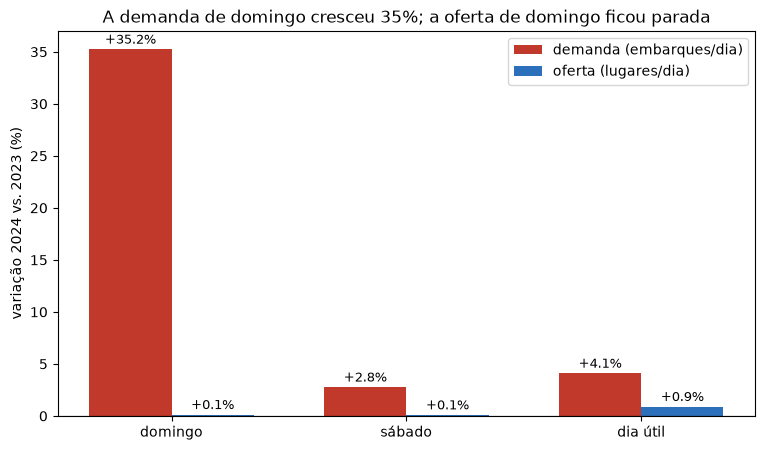

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(ORDEM_TIPO_DIA))
largura = 0.35
ax.bar(x - largura / 2, principal["pct_embarques"], largura, label="demanda (embarques/dia)", color="#c0392b")
ax.bar(x + largura / 2, principal["pct_lugares"], largura, label="oferta (lugares/dia)", color="#2c6fbb")
for i, (dem_v, ofe_v) in enumerate(zip(principal["pct_embarques"], principal["pct_lugares"])):
    # offset em pontos (nao em unidades de dado), senao o rotulo das barras minusculas cola no eixo
    ax.annotate(f"{dem_v:+.1f}%", (i - largura / 2, dem_v), textcoords="offset points",
                xytext=(0, 4), ha="center", fontsize=9)
    ax.annotate(f"{ofe_v:+.1f}%", (i + largura / 2, ofe_v), textcoords="offset points",
                xytext=(0, 4), ha="center", fontsize=9)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([ROTULO_TIPO_DIA[t] for t in ORDEM_TIPO_DIA])
ax.set_ylabel("variação 2024 vs. 2023 (%)")
ax.set_title("A demanda de domingo cresceu 35%; a oferta de domingo ficou parada")
ax.legend()
plt.savefig(DIR_IMG / "variacao_oferta_demanda_barras.png", **SALVAR_FIG)
plt.show()

## Seção 5 — a série mês a mês

As duas figuras abaixo usam a série **sem a exclusão do pré-política** — o objetivo aqui é justamente
ver a transição de dezembro de 2023 acontecendo. Feriados, atípicos e outliers continuam fora.

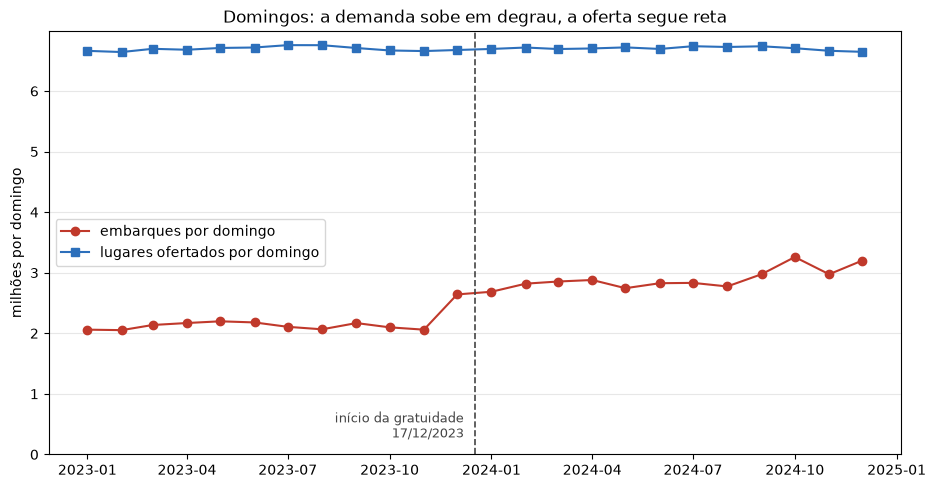

In [15]:
serie_dia = dias.loc[~(dias["feriado"] | dias["atipico"] | dias["outlier"])].copy()
serie_mes_dem = (serie_dia.groupby(["Ano", "Mes", "tipo_dia"])["embarques"].mean().reset_index())
serie = serie_mes_dem.merge(oferta_mes, on=["Ano", "Mes", "tipo_dia"], how="inner")
serie["periodo"] = pd.PeriodIndex(serie["Ano"] + "-" + serie["Mes"], freq="M").to_timestamp()
serie["lugares_por_embarque"] = serie["lugares"] / serie["embarques"]
serie = serie.sort_values("periodo")

INICIO = pd.Timestamp("2023-12-17")
# O transform misto (x em dado, y em fracao do eixo) nao aplica a conversao de unidade de
# data do matplotlib, entao o x da anotacao tem que ir ja convertido.
INICIO_NUM = mdates.date2num(INICIO)
dom = serie.loc[serie["tipo_dia"] == "domingo"]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(dom["periodo"], dom["embarques"] / 1e6, marker="o", color="#c0392b", label="embarques por domingo")
ax.plot(dom["periodo"], dom["lugares"] / 1e6, marker="s", color="#2c6fbb", label="lugares ofertados por domingo")
ax.axvline(INICIO, color="#444", linestyle="--", linewidth=1.2)
# ancorada no rodape do eixo (x em unidade de dado, y em fracao do eixo), para nao colidir
# com nenhuma das duas series
ax.annotate("início da gratuidade\n17/12/2023", xy=(INICIO_NUM, 0.03),
            xycoords=ax.get_xaxis_transform(), xytext=(-8, 0), textcoords="offset points",
            ha="right", va="bottom", fontsize=9, color="#444")
ax.set_ylabel("milhões por domingo")
ax.set_ylim(bottom=0)
ax.set_title("Domingos: a demanda sobe em degrau, a oferta segue reta")
ax.legend(loc="center left")
ax.grid(axis="y", alpha=0.3)
plt.savefig(DIR_IMG / "oferta_demanda_mensal.png", **SALVAR_FIG)
plt.show()

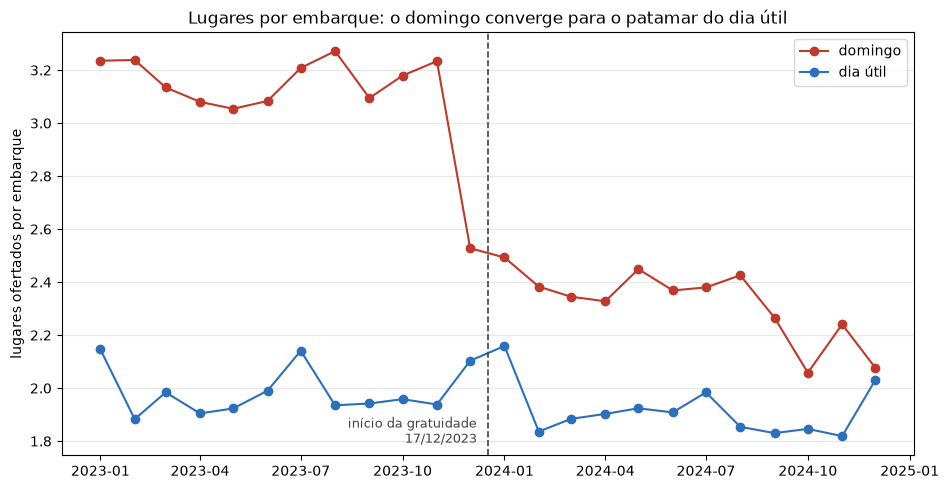

In [16]:
fig, ax = plt.subplots(figsize=(11, 5.5))
for tipo, cor in [("domingo", "#c0392b"), ("util", "#2c6fbb")]:
    s = serie.loc[serie["tipo_dia"] == tipo]
    ax.plot(s["periodo"], s["lugares_por_embarque"], marker="o", color=cor,
            label=ROTULO_TIPO_DIA[tipo])
ax.axvline(INICIO, color="#444", linestyle="--", linewidth=1.2)
ax.annotate("início da gratuidade\n17/12/2023", xy=(INICIO_NUM, 0.02),
            xycoords=ax.get_xaxis_transform(), xytext=(-8, 0), textcoords="offset points",
            ha="right", va="bottom", fontsize=9, color="#444")
ax.set_ylabel("lugares ofertados por embarque")
ax.set_title("Lugares por embarque: o domingo converge para o patamar do dia útil")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.savefig(DIR_IMG / "lugares_por_embarque_mensal.png", **SALVAR_FIG)
plt.show()

## Seção 6 — a data de início da política, lida no dado

A série oficial separa o total por modalidade de pagamento. Nos domingos, `of_pagantes` sai de mais
de metade do total para praticamente zero **entre 10 e 17 de dezembro de 2023** — é a assinatura da
gratuidade. Não é bug de parsing: é a política. (O mesmo colapso, no ano inteiro de 2024, está
documentado em `01_criacao_de_bases/03_cria_base_oficial.ipynb`.)

In [17]:
recorte = dia_oficial.loc[(dia_oficial["tipo_dia"] == "domingo")
                          & dia_oficial["data"].between("20231001", "20240211")].copy()
recorte["pct_pagantes"] = 100 * recorte["pagantes"] / recorte["embarques"]
recorte.index = pd.to_datetime(recorte["data"], format="%Y%m%d").dt.strftime("%d/%m/%Y")
recorte.index.name = "domingo"

inicio_politica = recorte[["embarques", "pagantes", "pct_pagantes"]]
inicio_politica.to_parquet(DIR_TABELAS / "inicio_politica.parquet")
print(inicio_politica.round(1).to_string())

            embarques   pagantes  pct_pagantes
domingo                                       
01/10/2023   732606.0   468846.0          64.0
08/10/2023  2058856.0  1140993.0          55.4
15/10/2023  2117085.0  1153813.0          54.5
22/10/2023  2198594.0  1194709.0          54.3
29/10/2023  2017023.0  1115142.0          55.3
05/11/2023   701114.0   431343.0          61.5
12/11/2023   738282.0   453456.0          61.4
19/11/2023  1895706.0  1053348.0          55.6
26/11/2023  2223187.0  1214540.0          54.6
03/12/2023  2418368.0  1343280.0          55.5
10/12/2023  2499183.0  1386686.0          55.5
17/12/2023  3006910.0     2831.0           0.1
24/12/2023  2563400.0      520.0           0.0
31/12/2023  2197182.0      393.0           0.0
07/01/2024  2709495.0      302.0           0.0
14/01/2024  2818123.0      209.0           0.0
21/01/2024  2599559.0     2325.0           0.1
28/01/2024  2614347.0      103.0           0.0
04/02/2024  2779248.0      286.0           0.0
11/02/2024  2

## Seção 7 — sensibilidade

Cada linha refaz a conta mudando **uma** escolha. O que interessa não são os valores individuais, e
sim que o sinal — domingo perdendo lugares por embarque muito mais rápido que o dia útil — sobrevive
a todas elas.

A última linha é a checagem cruzada com o resto do relatório: `03_comparacoes/compara_demanda_oferta_genero_idade.ipynb`
(Seção 8) publica **+35,95%** para o domingo, e esse número é a série oficial restrita aos **29
domingos que a bilhetagem entregou** (16 em 2023, 13 em 2024) dentro dos 4 meses. Sobre *todos* os
domingos dos mesmos meses o número é outro — a diferença é subamostragem de datas, não método.

In [18]:
DOMINGOS_BILHETAGEM = "../outputs/01/Dados_Domingos_2023_2024_zona_imputada.parquet"

def linha_sensibilidade(rotulo, base_demanda, meses, agregador="mean"):
    dem = base_demanda.loc[base_demanda["Mes"].isin(meses)]
    por_mes = dem.groupby(["Ano", "Mes", "tipo_dia"])["embarques"].agg(agregador)
    niveis = por_mes.groupby(level=["Ano", "tipo_dia"]).mean().rename("embarques").reset_index()
    ofe = (oferta_mes.loc[oferta_mes["Mes"].isin(meses)]
           .groupby(["Ano", "tipo_dia"])[["n_partidas", "lugares"]].mean().reset_index())
    t = niveis.merge(ofe, on=["Ano", "tipo_dia"], how="inner")
    t["razao"] = t["lugares"] / t["embarques"]
    p = t.pivot(index="tipo_dia", columns="Ano")
    pct = lambda col, tipo: 100 * (p[(col, "2024")][tipo] / p[(col, "2023")][tipo] - 1)
    return {
        "variante": rotulo,
        "pct_embarques_domingo": pct("embarques", "domingo"),
        "pct_embarques_util": pct("embarques", "util"),
        "pct_razao_domingo": pct("razao", "domingo"),
        "pct_razao_util": pct("razao", "util"),
        "sinal_pp": pct("razao", "domingo") - pct("razao", "util"),
    }


# Variante "bruta": mantem feriados, atipicos e outliers; so os 3 domingos ja tratados de
# dezembro/2023 continuam fora, porque inclui-los no "antes" nao e uma escolha de calendario,
# e sim contar periodo tratado como controle.
sem_limpeza = dias.loc[~dias["pos_politica_2023"]]

variantes = [
    linha_sensibilidade("12 meses, calendário limpo (principal)", demanda_dia, JANELA_PRINCIPAL),
    linha_sensibilidade("12 meses, mediana em vez de média", demanda_dia, JANELA_PRINCIPAL, "median"),
    linha_sensibilidade("12 meses, sem excluir feriados/atípicos/outliers", sem_limpeza, JANELA_PRINCIPAL),
    linha_sensibilidade("4 meses (janela do resto do relatório), limpo", demanda_dia, JANELA_SENSIBILIDADE),
    linha_sensibilidade("4 meses, sem excluir feriados/atípicos/outliers", sem_limpeza, JANELA_SENSIBILIDADE),
]

# Checagem cruzada: serie oficial restrita aos domingos que a bilhetagem entregou, 4 meses.
datas_entregues = set(duckdb.sql(
    f"SELECT DISTINCT data FROM read_parquet('{DOMINGOS_BILHETAGEM}')").df()["data"])
sub = dias.loc[(dias["tipo_dia"] == "domingo") & dias["data"].isin(datas_entregues)
               & dias["Mes"].isin(JANELA_SENSIBILIDADE)]
pm = sub.groupby(["Ano", "Mes"])["embarques"].mean().groupby(level="Ano").mean()
pct_subamostra = 100 * (pm["2024"] / pm["2023"] - 1)
print(f"Domingos entregues pela bilhetagem na janela de 4 meses: "
      f"{sub.groupby('Ano').size().to_dict()} -> {pct_subamostra:+.2f}% "
      f"(reproduz o +35,95% publicado na Secao 8 do notebook de comparacoes)")

sensibilidade_ocupacao = pd.DataFrame(variantes).set_index("variante")
sensibilidade_ocupacao.to_parquet(DIR_TABELAS / "sensibilidade_ocupacao.parquet")
print()
print(sensibilidade_ocupacao.round(1).to_string())

Domingos entregues pela bilhetagem na janela de 4 meses: {'2023': 16, '2024': 13} -> +35.95% (reproduz o +35,95% publicado na Secao 8 do notebook de comparacoes)

                                                  pct_embarques_domingo  pct_embarques_util  pct_razao_domingo  pct_razao_util  sinal_pp
variante                                                                                                                                
12 meses, calendário limpo (principal)                             35.2                 4.1              -26.0            -3.1     -22.9
12 meses, mediana em vez de média                                  36.3                 4.4              -26.5            -3.4     -23.1
12 meses, sem excluir feriados/atípicos/outliers                   41.6                 3.9              -29.3            -2.9     -26.3
4 meses (janela do resto do relatório), limpo                      37.4                 4.8              -26.9            -2.9     -24.0
4 meses, sem ex

## Conclusão

Aos domingos, entre 2023 e 2024, a demanda cresceu cerca de **35%** enquanto a oferta ficou
**estatisticamente parada** — variação de −0,2% em partidas programadas e +0,1% em lugares. A razão
lugares ofertados por embarque caiu **cerca de 26%**, contra ~3% no dia útil usado como controle:
um sinal isolado da ordem de **−23 pontos percentuais**.

As duas métricas de oferta — partidas (totalmente observada) e lugares (que depende da tabela de
capacidade nominal) — dão praticamente o mesmo resultado, então a conclusão não está apoiada na
tabela de capacidade. E nada aqui usa `zona_emb`, bilhetagem ou a janela de 4 meses.

O que o resultado **não** diz: onde na cidade a lotação piorou mais. Essa pergunta continua
dependendo do recorte por zona, com todas as ressalvas de imputação do resto do relatório.